# Exploratory Data Analysis

In [11]:
import os, sys, warnings
warnings.filterwarnings("ignore")

if os.path.basename(os.getcwd()) == "notebook":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 50, "display.width", 200)

## 1. Memuat data

In [2]:
train = pd.read_csv("data/splits/train.csv", parse_dates=["tanggal"])
val   = pd.read_csv("data/splits/val.csv",   parse_dates=["tanggal"])
test  = pd.read_csv("data/splits/test.csv",  parse_dates=["tanggal"])

train["split"], val["split"], test["split"] = "train", "val", "test"
panel = pd.concat([train, val, test], ignore_index=True).sort_values("tanggal").reset_index(drop=True)

rate = pd.read_csv("data/dateadjusted/rate.csv", parse_dates=["tanggal"]).sort_values("tanggal")
news = pd.read_csv("data/dateadjusted/cnbc.csv", parse_dates=["adjusted_date"])

print(f"Panel harian   : {panel.shape[0]} hari perdagangan x {panel.shape[1]} kolom")
print(f"Kalender JISDOR: {len(rate)} hari perdagangan")
print(f"Korpus berita  : {len(news)} artikel")
print(f"Rentang        : {panel['tanggal'].min():%Y-%m-%d} s/d {panel['tanggal'].max():%Y-%m-%d}")

# Pengelompokan kolom untuk analisis selanjutnya
kolom_lexicon = [c for c in panel.columns if "vader" in c or "lm_" in c]
kolom_svd     = [c for c in panel.columns if "svd_" in c]
print(f"\nFitur lexicon: {len(kolom_lexicon)} | Fitur TF-IDF/SVD: {len(kolom_svd)}")

Panel harian   : 1200 hari perdagangan x 161 kolom
Kalender JISDOR: 1202 hari perdagangan
Korpus berita  : 8679 artikel
Rentang        : 2021-09-03 s/d 2026-09-01

Fitur lexicon: 80 | Fitur TF-IDF/SVD: 75


## 2. Deret kurs USD/IDR

### 2.1 Level dan perubahan harian

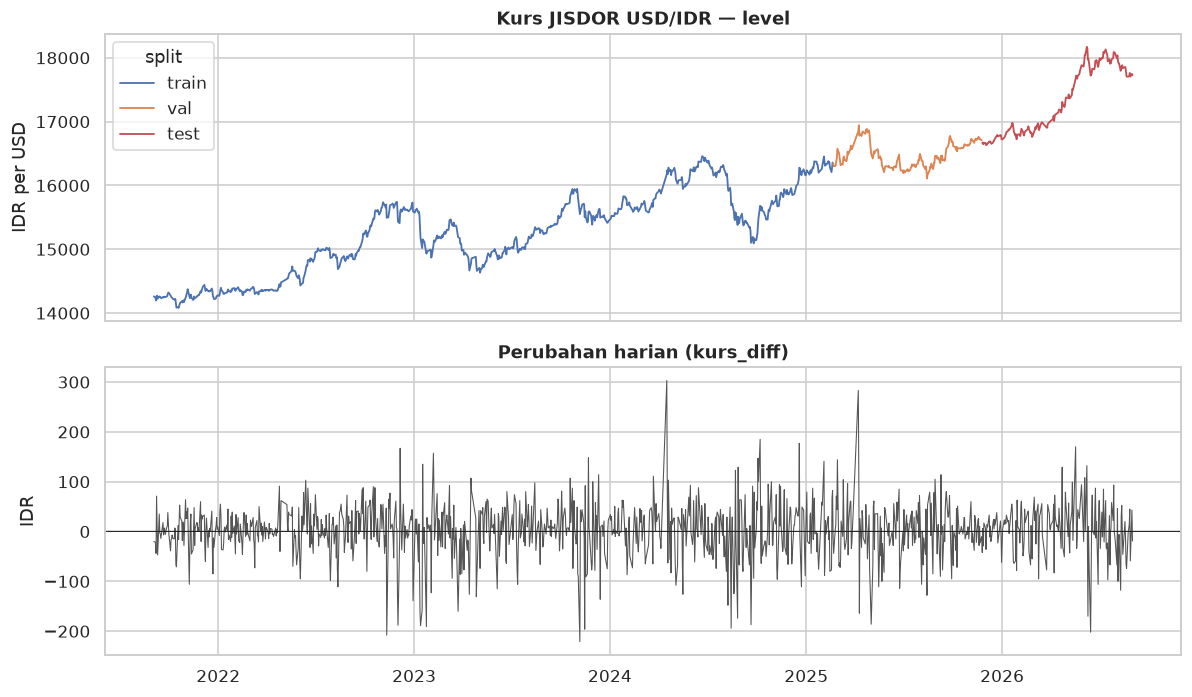

,min,max,mean
split,,,
train,14080,16458,15252
val,16109,16943,16479
test,16632,18171,17308


In [3]:
warna = {"train": "#4C72B0", "val": "#DD8452", "test": "#C44E52"}

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

for split, c in warna.items():
    bagian = panel[panel["split"] == split]
    axes[0].plot(bagian["tanggal"], bagian["kurs"], color=c, lw=1.2, label=split)
axes[0].set_title("Kurs JISDOR USD/IDR — level")
axes[0].set_ylabel("IDR per USD"); axes[0].legend(title="split")

axes[1].plot(panel["tanggal"], panel["kurs_diff"], lw=0.7, color="#555")
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_title("Perubahan harian (kurs_diff)")
axes[1].set_ylabel("IDR")
plt.tight_layout(); plt.show()

panel.groupby("split")["kurs"].agg(["min", "max", "mean"]).reindex(["train", "val", "test"]).round(0).astype(int)

Kurs bergerak dari sekitar 14.100 (2021) ke 18.200 (2026). Nilai maksimum periode train berada jauh di bawah nilai maksimum periode test.
Sehingga ketika XGBOOST ingin memprediksi datatest, XGBOOST tidak bisa memprediksi nilai yang ada di test case.

Inilah alasan target diformulasikan sebagai `kurs_diff` (selisih harian), yang berpusat di nol dan rentangnya stabil sepanjang waktu.

## 3. Korpus berita

### 3.1 Volume pemberitaan sepanjang waktu

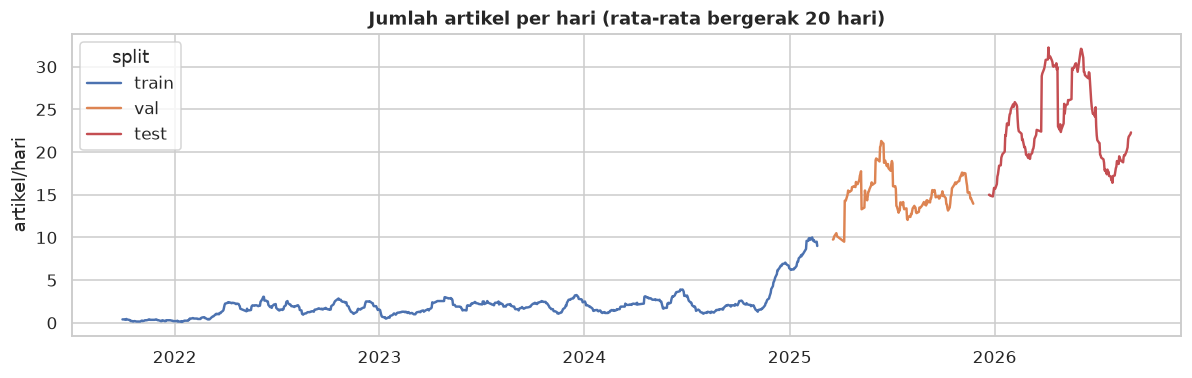

,rata_artikel,median_artikel,maks_artikel,hari_tanpa_berita
split,,,,
train,2.1,1.0,26.0,23.8%
val,14.7,13.0,101.0,0.0%
test,22.7,20.5,166.0,0.0%


In [4]:
fig, ax = plt.subplots(figsize=(11, 3.6))
for split, c in warna.items():
    bagian = panel[panel["split"] == split]
    ax.plot(bagian["tanggal"], bagian["news_count"].rolling(20).mean(),
            color=c, lw=1.6, label=split)
ax.set_title("Jumlah artikel per hari (rata-rata bergerak 20 hari)")
ax.set_ylabel("artikel/hari"); ax.legend(title="split")
plt.tight_layout(); plt.show()

ringkas = panel.groupby("split").agg(
    rata_artikel=("news_count", "mean"),
    median_artikel=("news_count", "median"),
    maks_artikel=("news_count", "max"),
    hari_tanpa_berita=("news_count", lambda s: (s == 0).mean()),
).reindex(["train", "val", "test"])
ringkas["rata_artikel"] = ringkas["rata_artikel"].round(1)
ringkas["hari_tanpa_berita"] = (ringkas["hari_tanpa_berita"] * 100).round(1).astype(str) + "%"
ringkas

### 3.2 Waktu terbit artikel dan penyelarasan temporal

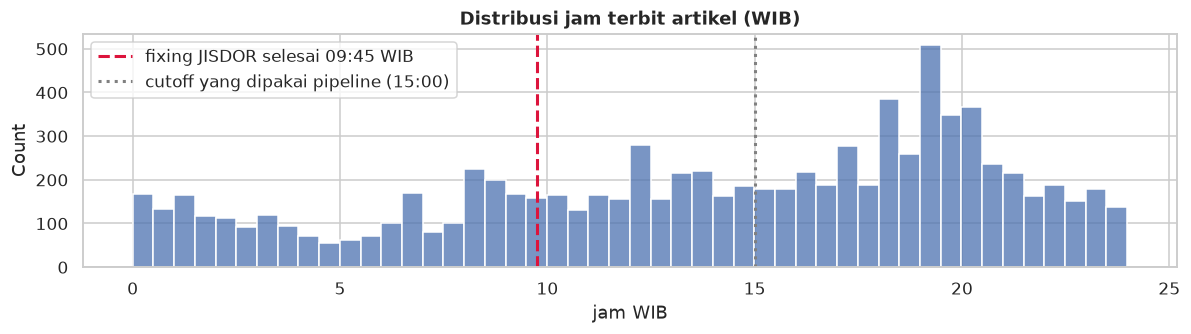

Artikel terbit antara 09:45 dan 15:00 WIB: 25.0% dari korpus


In [5]:
berita_mentah = pd.read_csv("data/processed/cnbc.csv")
wib = pd.to_datetime(berita_mentah["date"], utc=True, format="mixed").dt.tz_convert("Asia/Jakarta")

fig, ax = plt.subplots(figsize=(11, 3.2))
sns.histplot(wib.dt.hour + wib.dt.minute / 60, bins=48, ax=ax, color="#4C72B0")
ax.axvline(9.75, color="crimson", lw=2, ls="--", label="fixing JISDOR selesai 09:45 WIB")
ax.axvline(15.0, color="gray", lw=2, ls=":", label="cutoff yang dipakai pipeline (15:00)")
ax.set_title("Distribusi jam terbit artikel (WIB)")
ax.set_xlabel("jam WIB"); ax.legend()
plt.tight_layout(); plt.show()

antara = ((wib.dt.hour >= 9) & (wib.dt.hour < 15)).mean()
print(f"Artikel terbit antara 09:45 dan 15:00 WIB: {antara:.1%} dari korpus")

JISDOR dihitung dari transaksi antarbank pukul 08:00–09:45 WIB dan dipublikasikan sekitar 10:00 WIB. Artikel yang terbit pukul 10:00–14:59 WIB muncul **setelah** kurs hari itu ditetapkan.

Kalau fitur dipasangkan dengan kurs hari yang sama, ini akan menjadi *lookahead bias*. Namun pipeline menggeser seluruh kolom sentimen satu hari (`shift(1)`) di `arimax.py`, sehingga sentimen hari *t−1* dipakai untuk memprediksi perubahan menuju hari *t*. Berita pukul 14:59 pada hari *t−1* tetap mendahului fixing pukul 09:45 pada hari *t*, jadi **tidak ada kebocoran**.

### 3.3 Term paling menonjol (TF-IDF pada periode train)

Artikel periode train: 1781 dari 8679


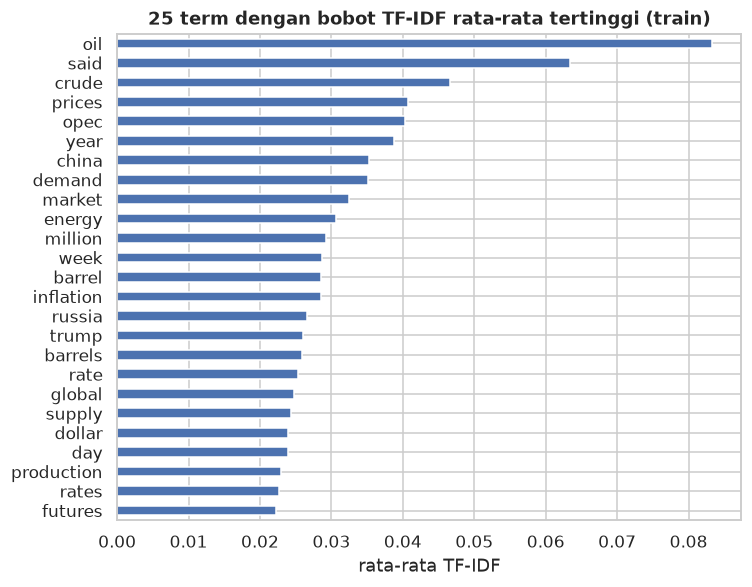

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

akhir_train = panel.loc[panel["split"] == "train", "tanggal"].max()
berita_train = news[news["adjusted_date"] <= akhir_train]
print(f"Artikel periode train: {len(berita_train)} dari {len(news)}")

vec = TfidfVectorizer(max_features=3000, stop_words="english", ngram_range=(1, 2), min_df=5)
X = vec.fit_transform(berita_train["full_text"].fillna("").astype(str))

skor = pd.Series(np.asarray(X.mean(axis=0)).ravel(), index=vec.get_feature_names_out())
teratas = skor.sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(7, 5.5))
teratas.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("25 term dengan bobot TF-IDF rata-rata tertinggi (train)")
ax.set_xlabel("rata-rata TF-IDF")
plt.tight_layout(); plt.show()

## 4. Fitur sentimen

### 4.1 Distribusi skor lexicon

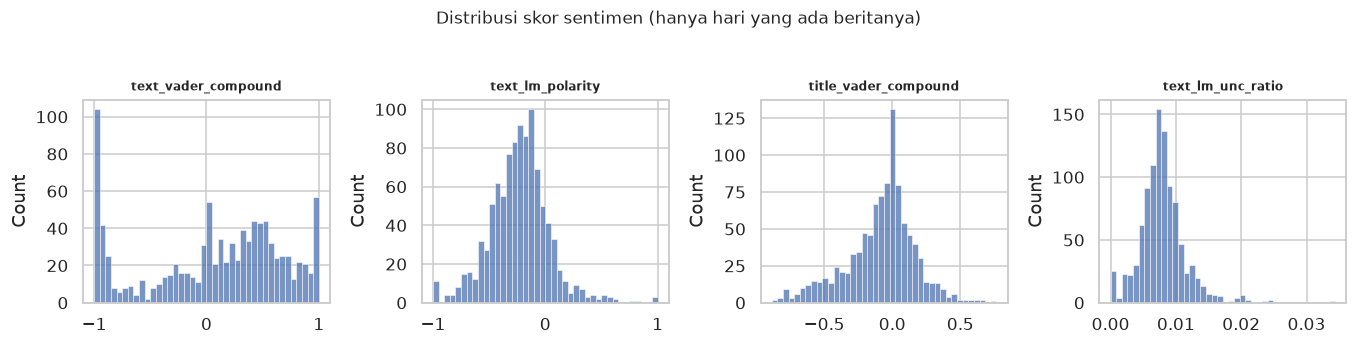

,count,mean,std,min,25%,50%,75%,max
text_vader_compound_mean,1000.0,0.0681,0.6160,-0.9994,-0.3524,0.1879,0.5325,0.9998
text_lm_polarity_mean,1000.0,-0.2336,0.2663,-1.0000,-0.3881,-0.2283,-0.0909,1.0000
title_vader_compound_mean,1000.0,-0.0849,0.2521,-0.8847,-0.2081,-0.0387,0.0570,0.7650
text_lm_unc_ratio_mean,1000.0,0.0079,0.0035,0.0000,0.0059,0.0076,0.0094,0.0344


In [7]:
fitur_utama = [
    "text_vader_compound_mean", "text_lm_polarity_mean",
    "title_vader_compound_mean", "text_lm_unc_ratio_mean",
]
fitur_utama = [c for c in fitur_utama if c in panel.columns]

fig, axes = plt.subplots(1, len(fitur_utama), figsize=(12.5, 3))
for ax, col in zip(np.atleast_1d(axes), fitur_utama):
    sns.histplot(panel.loc[panel["news_count"] > 0, col], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(col.replace("_mean", ""), fontsize=8); ax.set_xlabel("")
plt.suptitle("Distribusi skor sentimen (hanya hari yang ada beritanya)", y=1.04, fontsize=11)
plt.tight_layout(); plt.show()

panel.loc[panel["news_count"] > 0, fitur_utama].describe().T.round(4)

### 4.2 Apakah sentimen kemarin berkorelasi dengan perubahan kurs hari ini?

In [8]:
kandidat = [c for c in kolom_lexicon if c.endswith("_mean")]
tr = panel[panel["split"] == "train"]

korelasi = (
    tr[kandidat].corrwith(tr["kurs_diff"], method="spearman")
    .dropna().sort_values(key=np.abs, ascending=False).head(12)
    .rename("rho").to_frame()
)
korelasi["|rho|"] = korelasi["rho"].abs()
korelasi.round(4)

,rho,|rho|
title_lm_pos_mean,0.1046,0.1046
text_lm_pos_mean,0.1003,0.1003
text_vader_neu_mean,0.0845,0.0845
title_vader_pos_mean,0.0812,0.0812
text_lm_hit_mean,0.0805,0.0805
title_lm_hit_mean,0.0684,0.0684
text_lm_neg_mean,0.0594,0.0594
text_vader_neg_mean,0.0465,0.0465
title_lm_unc_ratio_mean,0.0455,0.0455
title_lm_unc_mean,0.0451,0.0451


**Temuan 6 — ada sinyal, tetapi tipis dan berada di ambang batas.**

Korelasi tertinggi yang teramati (|rho| ≈ 0,105) hanya sedikit melampaui ambang 95% distribusi null (≈ 0,099). Jadi hipotesis "semuanya kebetulan" bisa ditolak, tapi nyaris saja.

Dua hal perlu dicatat dalam membacanya:

- **Magnitudonya kecil secara absolut.** rho ≈ 0,1 berarti sentimen menjelaskan sekitar 1% variasi peringkat `kurs_diff`. Itu terlalu tipis untuk diharapkan menghasilkan perbaikan RMSE yang terlihat.
- **Ini korelasi monotonik sederhana.** Model nonlinear seperti XGBoost berpeluang menangkap hubungan yang tidak tertangkap Spearman — itulah salah satu alasan model tersebut tetap dijalankan di Notebook 2.

Uji permutasi seperti ini murah dan sebaiknya selalu dijalankan sebelum pemodelan: dengan puluhan kandidat fitur, korelasi "terlihat menarik" akan selalu muncul, dan uji ini memberi tolok ukur seberapa besar yang wajar muncul murni karena kebetulan.

### 4.3 Peta korelasi antarfitur

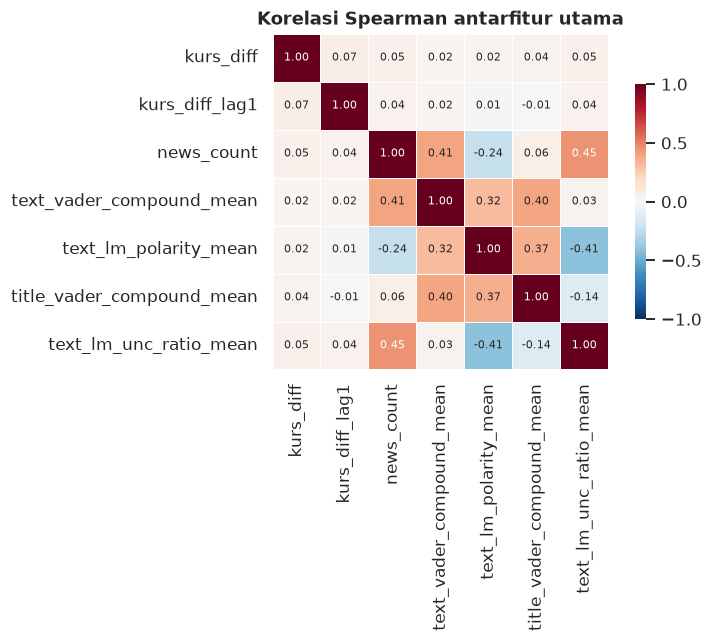

In [9]:
subset = ["kurs_diff", "kurs_diff_lag1", "news_count"] + fitur_utama
corr = panel[subset].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.7}, annot_kws={"size": 7}, ax=ax)
ax.set_title("Korelasi Spearman antarfitur utama")
plt.tight_layout(); plt.show()

## 5. Pembagian data

| Split | Porsi |
|---|---|
| Train | 70% | 
| Validation | 15% |
| Test | 15% |

In [10]:
ringkasan = (
    panel.groupby("split")
    .agg(n_hari=("tanggal", "size"), mulai=("tanggal", "min"), selesai=("tanggal", "max"),
         kurs_min=("kurs", "min"), kurs_maks=("kurs", "max"),
         artikel_per_hari=("news_count", "mean"),
         porsi_naik=("kurs_diff", lambda s: (s > 0).mean()))
    .reindex(["train", "val", "test"])
)
ringkasan["artikel_per_hari"] = ringkasan["artikel_per_hari"].round(1)
ringkasan["porsi_naik"] = (ringkasan["porsi_naik"] * 100).round(1).astype(str) + "%"
ringkasan

,n_hari,mulai,selesai,kurs_min,kurs_maks,artikel_per_hari,porsi_naik
split,,,,,,,
train,840,2021-09-03,2025-02-19,14080,16458,2.1,55.6%
val,180,2025-02-20,2025-11-24,16109,16943,14.7,52.2%
test,180,2025-11-25,2026-09-01,16632,18171,22.7,57.8%
